In [32]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import threshold_otsu
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [33]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("Assets"):
    sub_folder_files = os.listdir(os.path.join("Assets", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 450
Kelas: ['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']


In [34]:
def median_filter(img, size):
    h, w = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    area = size * size
    target = area // 2 
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            
            counts = [0] * 256
            for row in region:
                for val in row:
                    counts[int(val)] += 1
            
            current_sum = 0
            for val in range(256):
                current_sum += counts[val]
                if current_sum > target:
                    canvas[i, j] = val
                    break
    return canvas

kernel = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

In [35]:
def threshold_otsu_method(image):
    batas = threshold_otsu(image)   # ← batas dihitung otomatis
    hasil = np.copy(image)
    hasil[hasil >= batas] = 255
    hasil[hasil < batas] = 0
    return hasil

def masking(image, mask):
    height, width = image.shape

    new_img = np.zeros((height, width))  # ← canvas hitam
    for i in range(height):
        for j in range(width):
            if mask[i][j] != 0:          # ← cek mask
                new_img[i][j] = image[i][j]  # ← salin piksel
    return new_img

def dilasi(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='constant', constant_values=0)

    hasil = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            hasil[i, j] = np.max(window)

    return hasil

def erosi(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='constant', constant_values=255)

    hasil = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            hasil[i, j] = np.min(window)

    return hasil

In [36]:
size = (128, 128)
def pre_proses4(image, target_size=size):
    resized = cv.resize(image, target_size)
    
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    img = median_filter(gray, 3)
    img = threshold_otsu_method (img)
    img = masking (gray, img)
    img = erosi (img)
    img = dilasi (img)

    return img

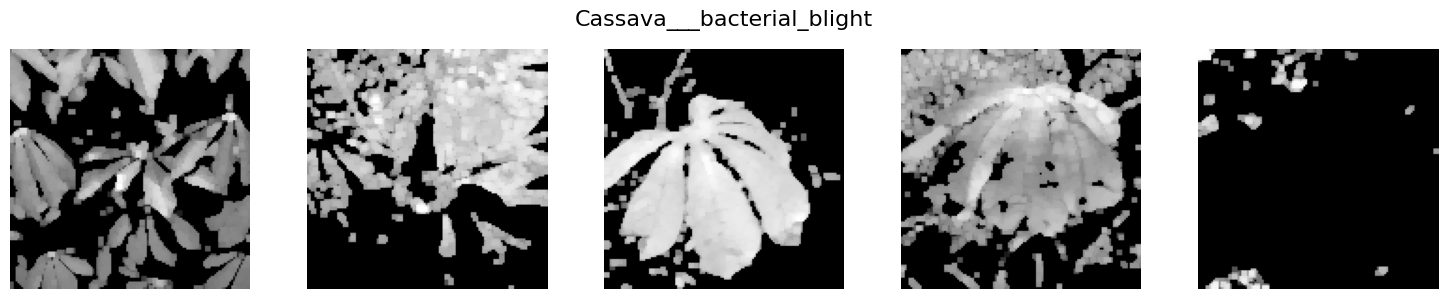

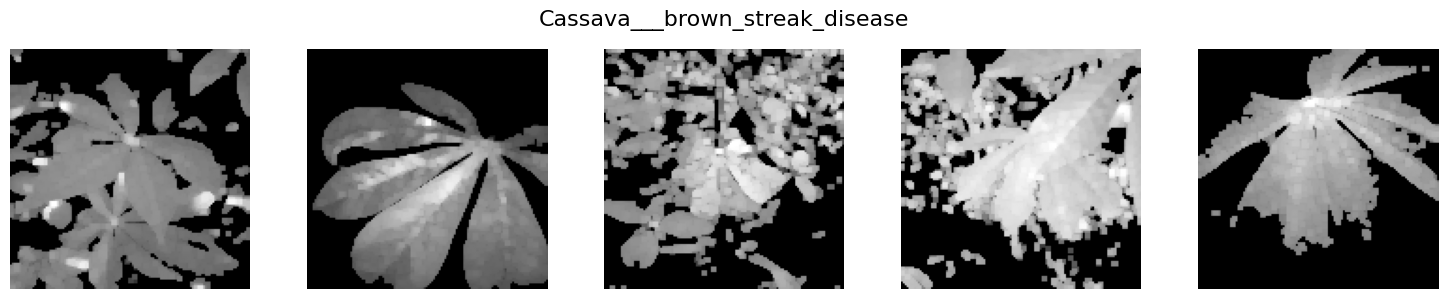

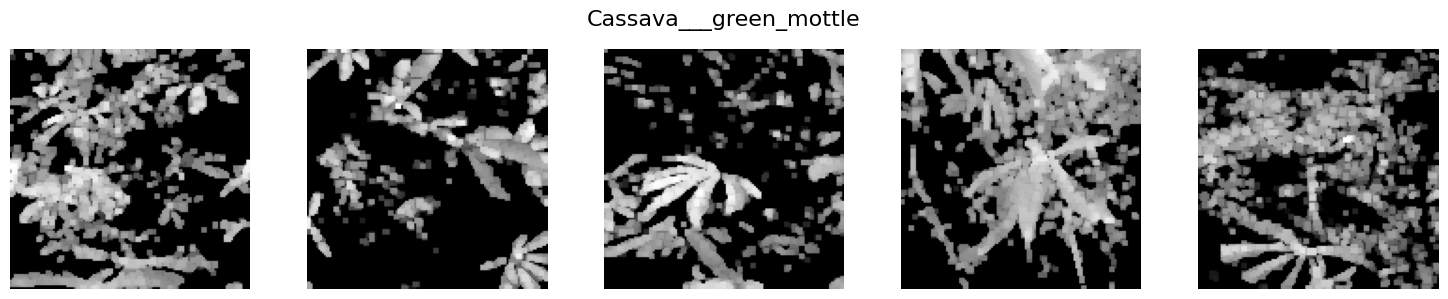

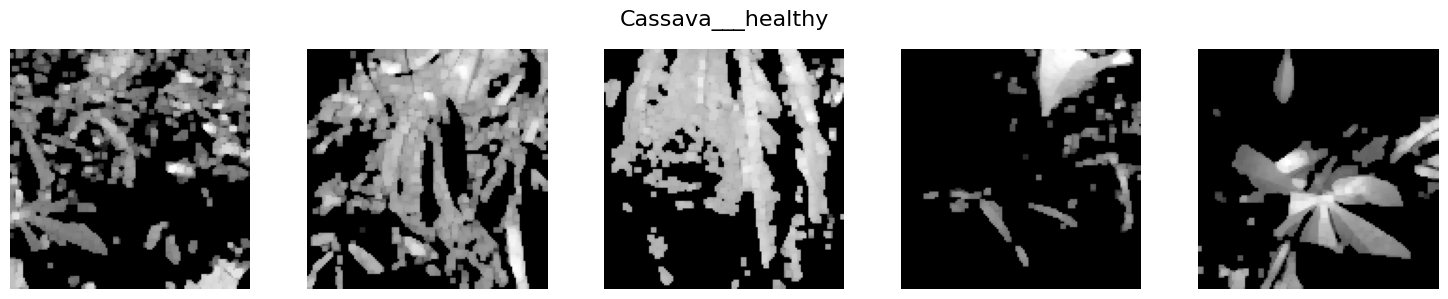

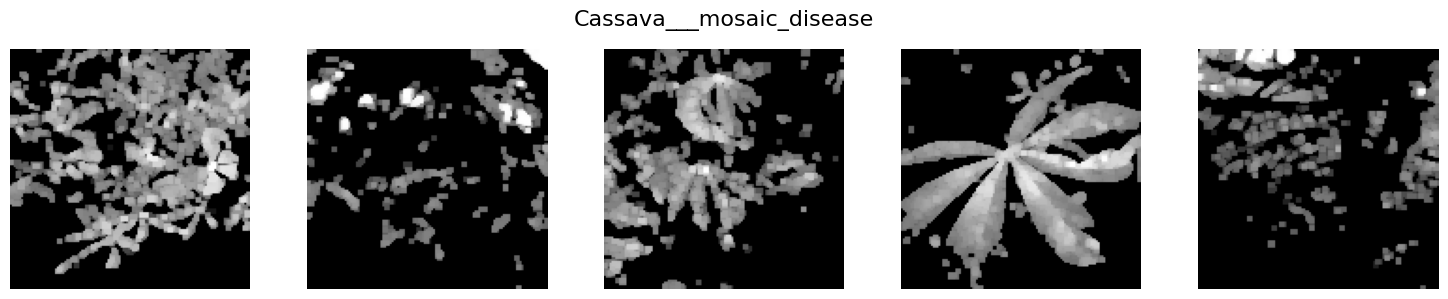

In [37]:
def percobaan4(img):
    hasil = pre_proses4(img)
    return hasil

dataPreprocessed = [percobaan4(img) for img in data]
unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    fig, axs = plt.subplots(1, 5, figsize=(15, 3)) 
    fig.suptitle(label, fontsize=16)

    for k in range(5):
        ax = axs[k]
        
        if k < len(idxs):
            ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')

        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

In [38]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image.astype(np.uint8), [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [39]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [40]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 450 citra.


In [41]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('./Hasil_ekstraksi/hasil_ekstraksi_Percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('./Hasil_ekstraksi/hasil_ekstraksi_Percobaan3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Cassava___bacterial_blight_1.jpg,Cassava___bacterial_blight,998.919845,1430.078058,882.300381,1358.039804,0.671181,0.566357,0.702780,0.565718,...,0.179061,0.165440,0.418853,0.403297,0.423156,0.406743,0.873269,0.818764,0.888003,0.827894
1,Cassava___bacterial_blight_2.jpg,Cassava___bacterial_blight,1138.293000,1805.400831,1278.802965,1925.356377,0.702384,0.577622,0.702558,0.572841,...,0.175942,0.163024,0.421552,0.405810,0.419454,0.403763,0.919751,0.872670,0.909804,0.864208
2,Cassava___bacterial_blight_3.jpg,Cassava___bacterial_blight,1101.736282,1757.101866,1090.593381,1644.021514,0.751441,0.666897,0.765240,0.662325,...,0.263909,0.249255,0.513399,0.498170,0.513720,0.499254,0.938082,0.901395,0.938728,0.907743
3,Cassava___bacterial_blight_4.jpg,Cassava___bacterial_blight,879.807148,1429.656023,924.997478,1289.984934,0.625388,0.472923,0.628448,0.482912,...,0.086823,0.078841,0.293928,0.276495,0.294658,0.280787,0.911296,0.855658,0.906859,0.869752
4,Cassava___bacterial_blight_5.jpg,Cassava___bacterial_blight,414.242126,747.684791,473.406927,638.850952,0.964652,0.947300,0.964012,0.948248,...,0.874202,0.868727,0.934619,0.930692,0.934987,0.932055,0.883968,0.784962,0.864210,0.816067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Cassava___mosaic_disease_86.jpg,Cassava___mosaic_disease,331.289616,878.296299,679.541892,811.296733,0.958802,0.936848,0.957053,0.938604,...,0.838604,0.833067,0.918401,0.911670,0.915753,0.912725,0.941779,0.843470,0.878430,0.855411
446,Cassava___mosaic_disease_87.jpg,Cassava___mosaic_disease,803.861282,1228.644119,802.413755,1308.672143,0.880161,0.830253,0.880429,0.827309,...,0.619343,0.603104,0.788764,0.777528,0.786983,0.776598,0.896518,0.842097,0.896719,0.831812
447,Cassava___mosaic_disease_88.jpg,Cassava___mosaic_disease,923.593442,1513.399591,1023.286479,1463.960444,0.686977,0.553007,0.686378,0.553985,...,0.165868,0.153773,0.409201,0.389620,0.407269,0.392138,0.906521,0.846668,0.896416,0.851675
448,Cassava___mosaic_disease_89.jpg,Cassava___mosaic_disease,1094.146223,1820.123628,1176.313546,1625.637671,0.710985,0.581140,0.709420,0.584407,...,0.207835,0.194103,0.458805,0.436004,0.455889,0.440571,0.896001,0.827002,0.888150,0.845484


Fitur sebelum seleksi: 28
Fitur setelah seleksi: 9
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


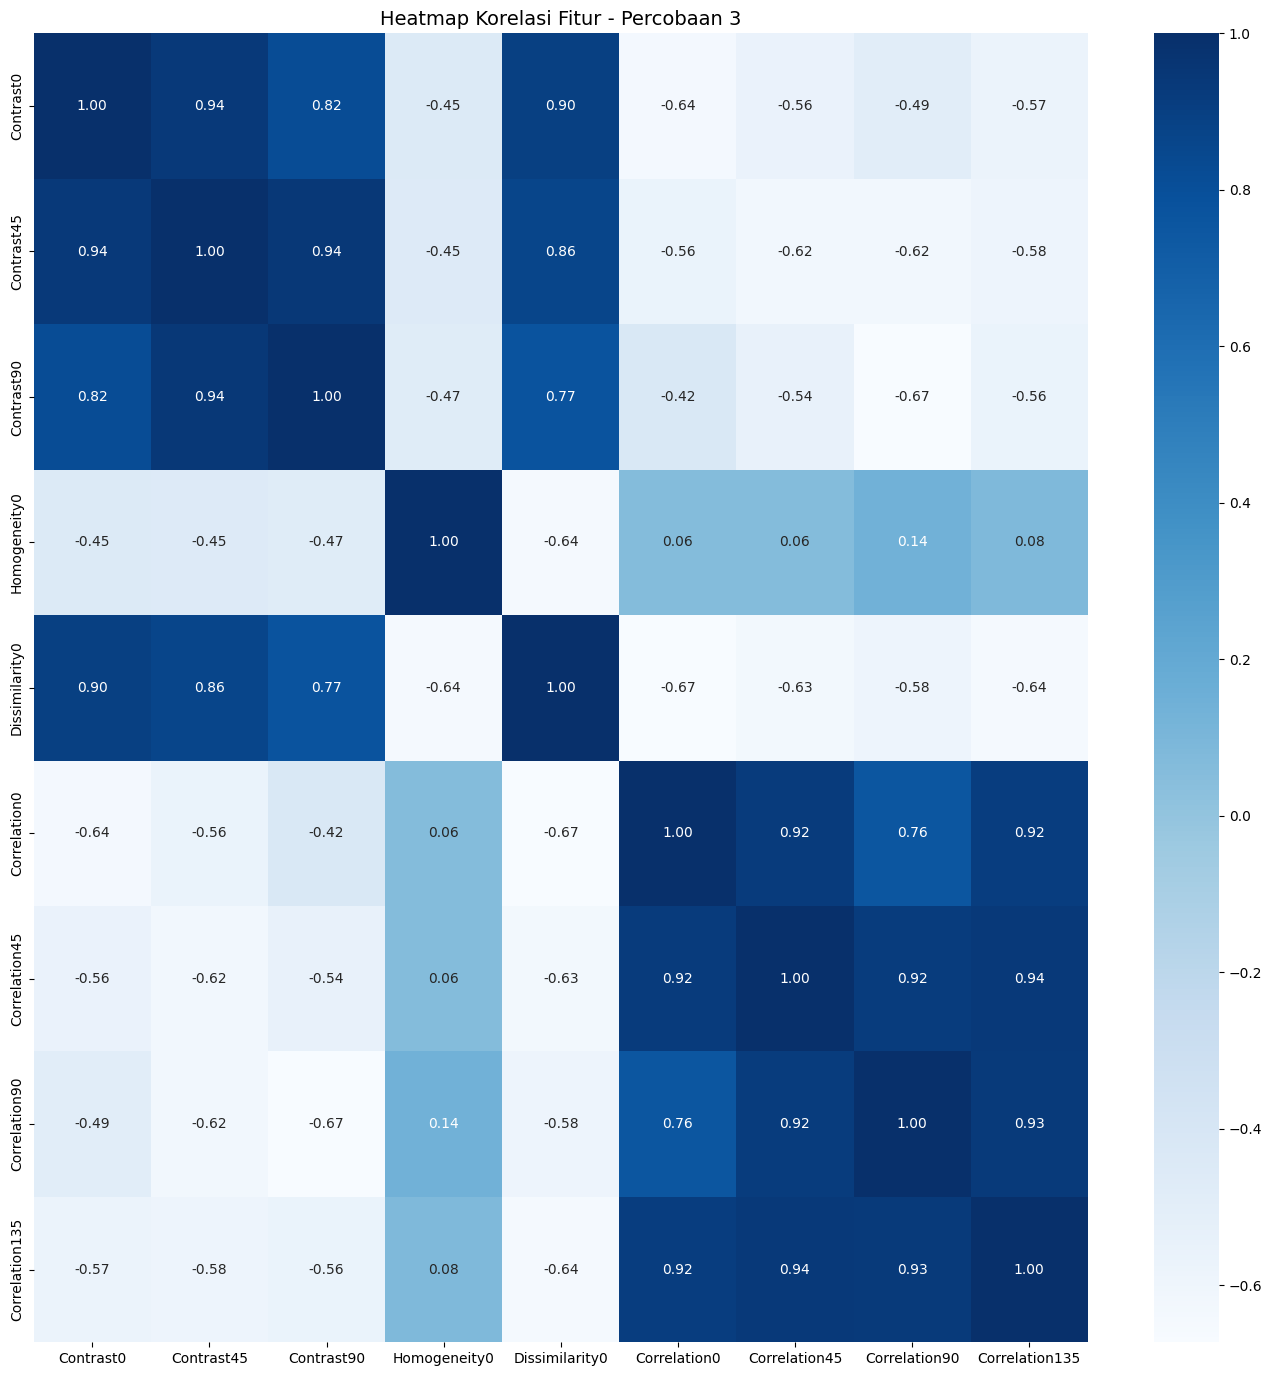

In [42]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}")
print(f"Fitur setelah seleksi: {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

In [43]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (360, 9)
X_test shape:  (90, 9)


In [44]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

In [45]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))
    
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [46]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.84      0.94      0.89        66
Cassava___brown_streak_disease       0.89      0.88      0.89        75
        Cassava___green_mottle       0.93      0.88      0.91        78
             Cassava___healthy       0.91      0.93      0.92        73
      Cassava___mosaic_disease       0.92      0.85      0.89        68

                      accuracy                           0.90       360
                     macro avg       0.90      0.90      0.90       360
                  weighted avg       0.90      0.90      0.90       360

[[62  2  1  1  0]
 [ 4 66  1  3  1]
 [ 4  0 69  2  3]
 [ 1  2  1 68  1]
 [ 3  4  2  1 58]]
Accuracy: 0.8972222222222223

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.36      0.42      0.38        24
Cassava___brown_streak_disease    

In [47]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.46      0.32      0.38        66
Cassava___brown_streak_disease       0.41      0.60      0.49        75
        Cassava___green_mottle       0.41      0.44      0.42        78
             Cassava___healthy       0.76      0.18      0.29        73
      Cassava___mosaic_disease       0.42      0.65      0.51        68

                      accuracy                           0.44       360
                     macro avg       0.49      0.44      0.42       360
                  weighted avg       0.49      0.44      0.42       360

[[21 21 10  1 13]
 [ 7 45 13  2  8]
 [ 4 17 34  1 22]
 [ 8 19 15 13 18]
 [ 6  8 10  0 44]]
Accuracy: 0.4361111111111111

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.25      0.12      0.17        24
Cassava___brown_streak_disease   

In [48]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.50      0.67      0.57        66
Cassava___brown_streak_disease       0.54      0.57      0.55        75
        Cassava___green_mottle       0.44      0.47      0.45        78
             Cassava___healthy       0.55      0.37      0.44        73
      Cassava___mosaic_disease       0.48      0.41      0.44        68

                      accuracy                           0.50       360
                     macro avg       0.50      0.50      0.49       360
                  weighted avg       0.50      0.50      0.49       360

[[44  6  7  2  7]
 [14 43  7  4  7]
 [13 10 37  9  9]
 [11 13 15 27  7]
 [ 6  8 19  7 28]]
Accuracy: 0.49722222222222223

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.56      0.42      0.48        24
Cassava___brown_streak_disease  

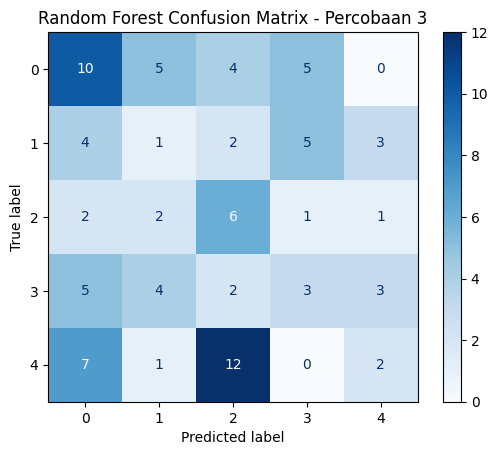

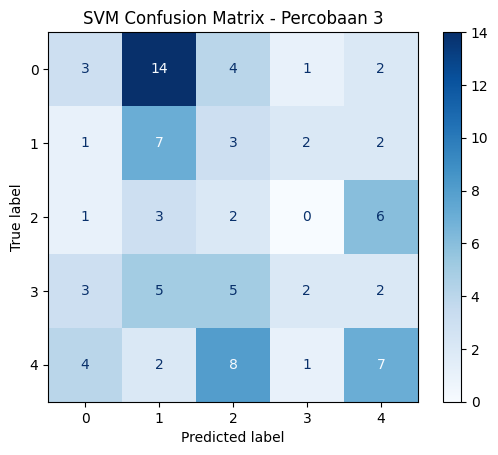

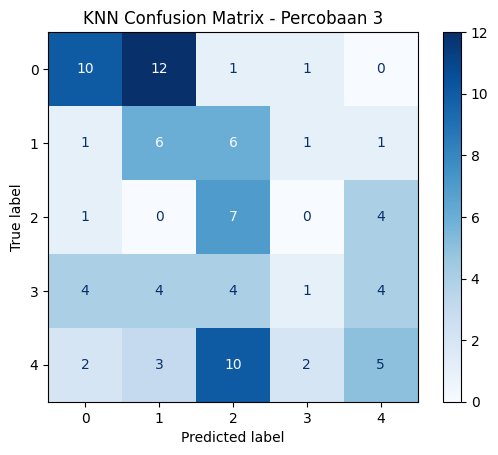

In [49]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 3")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 3")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 3")

In [50]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./Hasil_klasifikasi/hasil_klasifikasi_Percobaan3.csv', index=False)
df_hasil

,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.897222,0.244444,0.233625,0.244444,0.224674
1,SVM,0.436111,0.233333,0.269444,0.233333,0.227174
2,KNN,0.497222,0.322222,0.346561,0.322222,0.308724
